######################################################################################

IMPORTING DATA FROM NEO TXT FILE

######################################################################################

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import openpyxl as opxl
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

import sys
sys.path.insert(1,'C:\\Users\\sws5\\Documents\\GitHub\\RNASynBioScene\\')
from concentration_calibrations import concentration_calibrations
from create_exp_IDs import create_exp_IDs
from import_neo_data import import_neo_data
from user_defined_plots import user_defined_plots


'''
##############################################################################
USER DEFINED FILE LOCATION AND PLATE POSITIONS FOR IMPORTING
##############################################################################
'''


# PATH
results_path = 'C:\\Users\\sws5\\OneDrive - NIST\\Presentations and write ups\\bnext DevNotes\\'
folder_path = 'Nucleus Cytosol Demo\\'
file_name ='2026_05_12_cytosol.txt'
file_path = folder_path+file_name
full_path = results_path+folder_path


txt_encode = 'UTF-8' # the encoding of the text file for loading ...

plate_start = 'A1' # first well to start at for data import (no longer know what this does?)
plate_type  = '384'

partial_plate = 0 # 0 if the full plate was read, otherwise the number of rows the partial plate read spans


sNames = ['0','o','1','2','13','14','22','23','49','98'] # names of samples (optional)

rep1 = ['I16','I17','I18','I19','I20']
rep2 = []
rep3 = []

plate_positions = rep1 + rep2 + rep3

nSamples = len(rep1)
nReps = int(len(plate_positions)/nSamples)


nChannels = ['CFP','Reacted MB','Pepper','FAM'] # names of the channels being measured / imported (optional)
# header in text file to start pulling data from
skip_delim = ['Read 1:430,475','Read 1:524,565','Read 2:577,620','Read 2:485,510']
# next header in text file to stop pulling data
row_stop_delim = ['Read 1:524,565','Read 2:577,620','Read 2:485,510','Results']

# Use normalized reporter data (0) or (1)
use_norm = 1 # normalize the molecular beacon data between 0 and 100 %
mb_hc = 0 # specify a maximum signal to use for normalizaton, if set to 0 then the maximum will be taken from the data


# Converting to concentration
convert_to_con = 0 # convert the signals to concentrations with calibration curves
lysate_type = [4] # -1 for IVT, 0 for PURE, 1 for BL21 DE3 Star lysate, 2 for BL21 DE3 lysate, 3 for NEBexpress lysate,  4 for Nucleus Cytosol, 
CFP_chan = 0 # -1 if not present
MB_chan = 1 # -1 if not present
PPr_chan = 2 # -1 if not present
MB_con = 0.5 # concentration of molecular beacon used


font = 'MS Reference Sans Serif'
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams['font.sans-serif'] = ['MS Reference Sans Serif']


data_dict, DDn_dict, DDn_mean, DDn_std, t, chan_names_dash = import_neo_data(
                                                                results_path, 
                                                                file_path, 
                                                                skip_delim, 
                                                                row_stop_delim, 
                                                                plate_type, 
                                                                plate_positions, 
                                                                rep1,
                                                                nReps,
                                                                nSamples,
                                                                lysate_type,
                                                                plate_start,
                                                                convert_to_con, 
                                                                partial_plate, 
                                                                txt_encode,
                                                                MB_con, 
                                                                CFP_chan, 
                                                                MB_chan, 
                                                                PPr_chan,
                                                                use_norm,
                                                                mb_hc)

###############################################################################

SAVING ALL KINETIC DATA TO EXCEL FILE - option to create exp IDs for tiddy data

###############################################################################

In [2]:

save_loc = full_path
save_name = 'Nucleus_Cytosol_Demo'

# save_loc = results_path+folder_path # saving in same folder the text file data was pulled from
# save_name = file_name[:-4] # same name as the text file name

wb = opxl.Workbook() # to create a new workbook
#wb = opxl.load_workbook(save_loc+save_name+'.xlsx') # to append to an existing workbook


# Experimental conditions 

constructs = [['Io','(IN_1) I{u1d} [], [d20 Thyb10]','(IN_2) I{u1d} [], [d1 Thyb10]','(IN_3) I{u1d} [], [d5 Thyb10]','(IN_4) I{u1d} [], [d10 Thyb10]'],
              '(G_1) G{u1,rbs2} [s4u], [], [R3 CFP PPr Thyb10]']
molecules = ['dna','dna']
construct_cons = np.array([[5,5,5,5,5], # construct 1
                           [5,5,5,5,5 ]]) # construct 2

###################################
# Saving experimental IDs
###################################
wb = create_exp_IDs(folder_path,wb,plate_positions,nSamples,nReps,molecules,constructs,construct_cons,lysate_type)


###################################
# Saving all individual replicates
###################################
for j in range(len(skip_delim)):
    
    i = len(skip_delim)-(j+1) # creating sheets in the same order they are specified above
    
    ws1 = wb.create_sheet(chan_names_dash[i],0) # giving each sheet name the names of the channels
    
    ws1.cell(1,1,file_name) # saving raw data file
    ws1.cell(2,1,'Raw data') # saving raw data file
    ws1.cell(3,1,'time (min)') # saving raw data file
    
    # saving time data
    for m in range(len(t[i])):
        ws1.cell(m+4,1,t[i][m,0]*60) 
    
    # saving raw data
    for n in range(len(plate_positions)):
        ws1.cell(3,n+2,plate_positions[n])
        for p in range(len(t[i])):
            ws1.cell(p+4,n+2,data_dict[i][plate_positions[n]][p]) 
    
    # saving normalized data if applicable
    if convert_to_con == 1:
        for n in range(len(plate_positions),2*len(plate_positions)):
            ws1.cell(2,len(plate_positions)+3,'Concentration data')
            ws1.cell(3,n+3,plate_positions[n-len(plate_positions)])
            for p in range(len(t[i])):
                ws1.cell(p+4,n+3,DDn_dict[i][plate_positions[n-len(plate_positions)]][p])         
    
wb.save(save_loc+save_name+'.xlsx')

0
0
0
1
0
2
0
3
0
4


###############################################################################

PLOTTING USER DEFINED WELLS (KINETICS)

###############################################################################

For cell experiments this block of code assumes the OD600 readings are in
position 0 (the first read in the imported data)

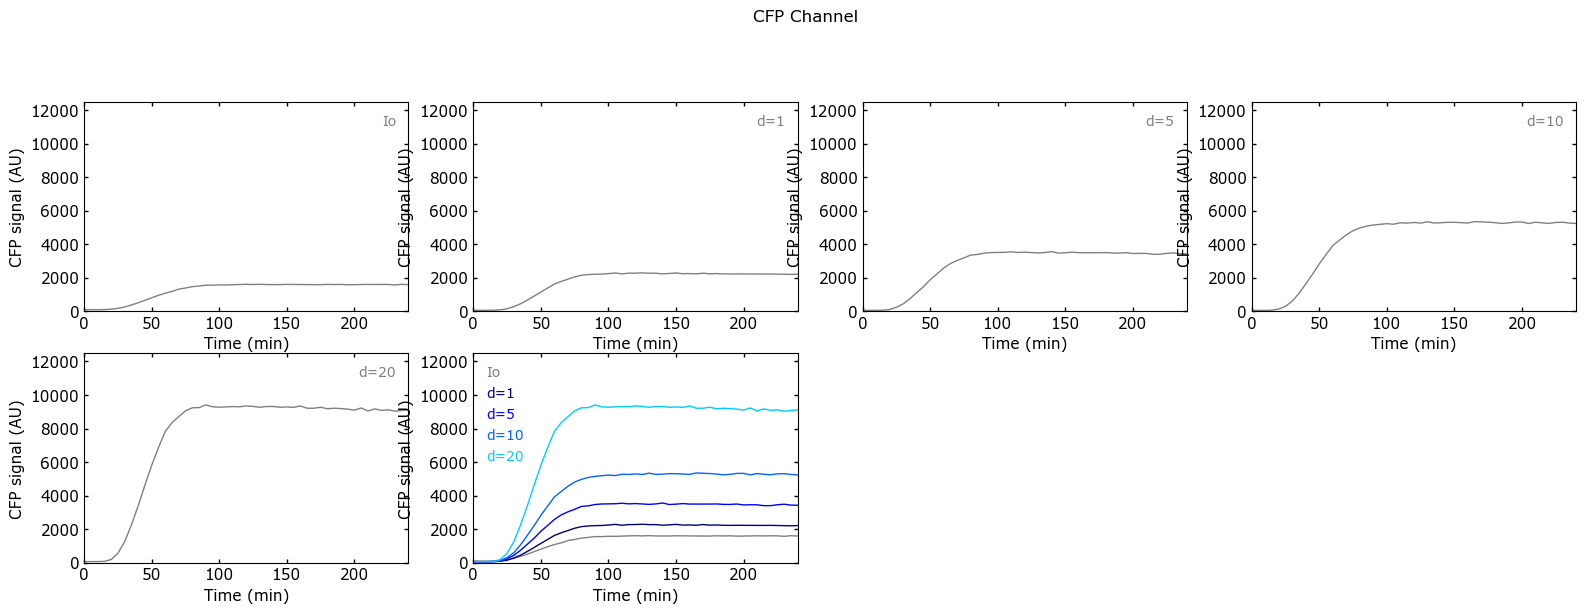

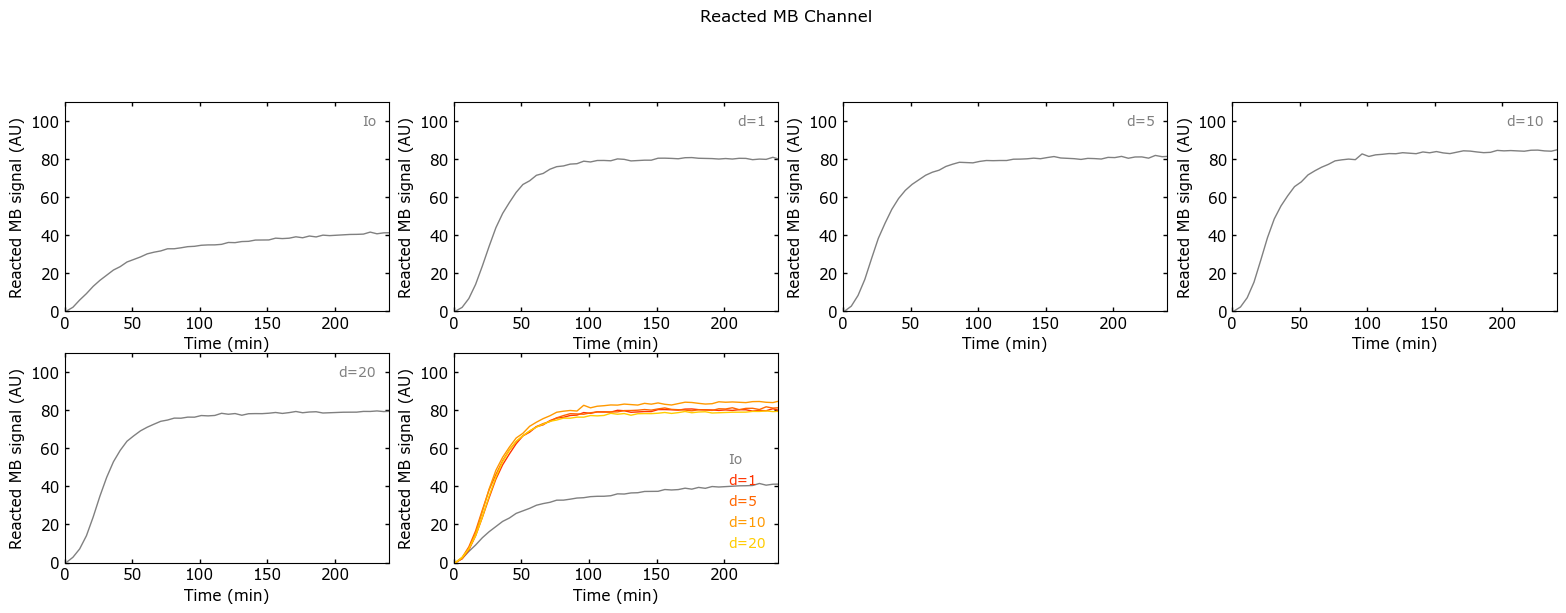

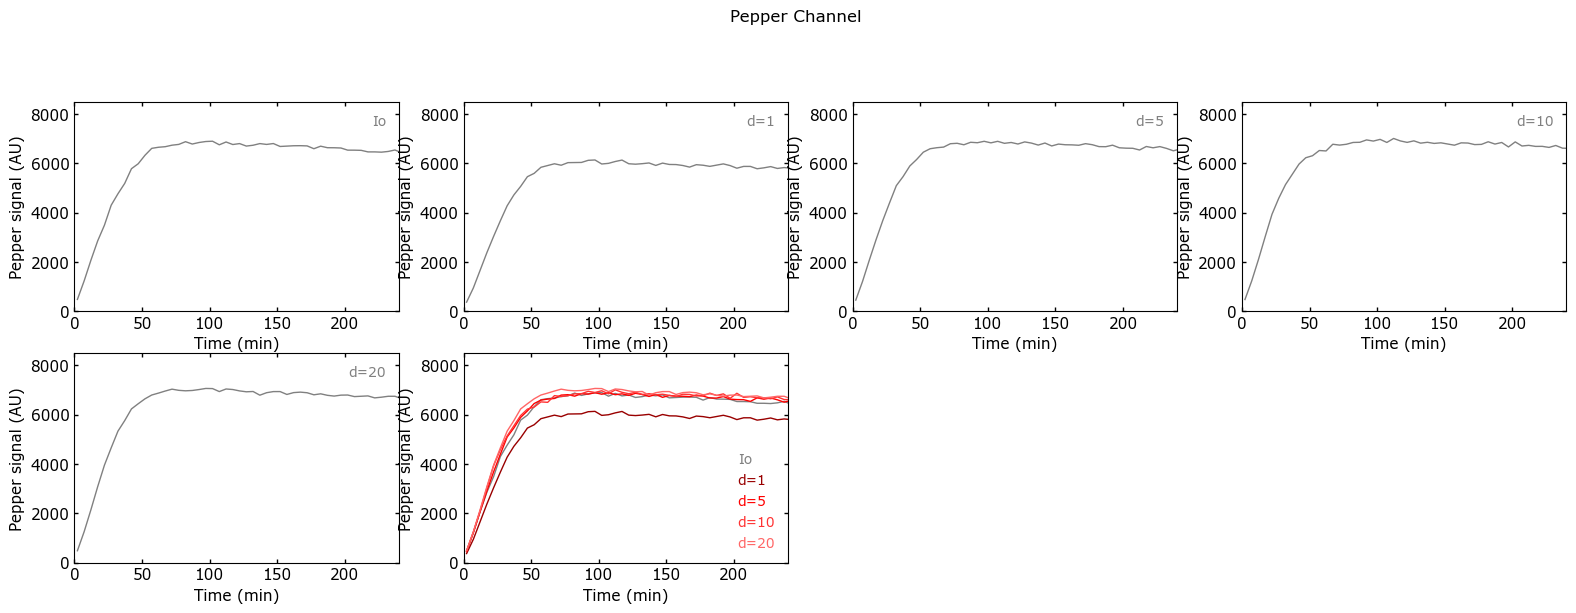

In [6]:

fs = 11 # fontsize for the axes and labels
ts = 0 # time shift if the experiment doesnt begin at time = 0 
tpt = 4*60 # time to plot until (minutes)
plot_reps = 1 # plot the individual plots of samples
plot_mean = 0 # plot the mean and std of samples
plt_leg = 1 # put a plot legend
full_y_label = 1 # put y labels on all subplots
y_units = '\u03bcmol/L' # units for y-axis if concentrations are used
x_units = 'min' # units for x-axis
y_dec = 0 # number of decimal places to use on y-axis

# These two below only apply to cell experiments
FLOD = 0 # plot fluorescence / OD for cell data - assumes OD is position 0 of channels
corrOD = 0 # correct OD by subtracting initial timepoint


# specify subplot rows and columns 
spR = 3 # number of rows
spC = 4 # number of columns
figW = 19.25 # figure width
figH = 9.25 # figure height
im_tag = '' # optional text to add to the end of the image filenames (for saving different variations of plots in the same folder)

# max for y axis  for each channel
yMax = [4,0.55,2]
yMax = [12500,110,8500]

alp = 1
# colors for each sample you want to plot, each internal list corresponds to the samples in nSamples_sub below
cSamples = [
            [[0.5,0.5,0.5],[0,0,0.5],[0,0,1],[0,0.4,1],[0,0.8,1],[0,1,1]],
            [[0.5,0.5,0.5],[1,0.2,0],[1,0.4,0],[1,0.6,0],[1,0.8,0],[1,0.9,0],[1,1,0]],
            [[0.5,0.5,0.5],[0.6,0,0],[1,0,0],[1,0.2,0.2],[1,0.4,0.4],[1,0.5,0.5]]]

# specify which channels to plot (position in skip_delim in first section)
nChannels_sub = [0,1,2]


# specify which samples to plot, each list will be a separate subplot
nSamples_sub = [
                ['I16'],
                ['I18'],
                ['I19'],
                ['I20'],
                ['I17'],
                ['I16','I18','I19','I20','I17']]


# legends for each subplot
leg_list =     [
                ['Io'],
                ['d=1'],
                ['d=5'],
                ['d=10'],
                ['d=20'],
                ['Io','d=1','d=5','d=10','d=20']]  

# for plots with different number of lines and there is a desire to use different colors
# if this remains empty then plots will follow cSamples above, if filled in it must match the arrangement of nSamples_sub and leg_list - with each list having the positions of cSamples to use per subplot
color_list = [[0],
              [1],
              [2],
              [3],
              [4],
              [0,1,2,3,4]]

# Can change the line styles here for each line of the plot
ls = ['-','-','-','-','-','-','-','-','-','-','-','-','-','-','-']


# Plotting function
user_defined_plots(t, DDn_dict, DDn_mean, DDn_std, plate_positions, nChannels, nChannels_sub, nSamples_sub, full_path,
                    nReps, nSamples, cSamples, yMax, tpt, spR, spC, figW, figH, fs, ts, y_units, x_units, 
                    plot_reps, plot_mean, FLOD, corrOD, plt_leg, leg_list, 
                    ls, convert_to_con, rep1, rep2, full_y_label, y_dec,im_tag)    
             


###############################################################################

BAR PLOTS AT A SPECIFIC TIME POINT

###############################################################################

In [ ]:


tpt = 90 # time (min) to take fluorescence value for bar plot
tptLoc = np.where(np.round(t[0]*60,-1)==tpt)[0][0]


# names of samples (these are now needed for the x-axis of the bar plot)
sNames = ['0I/0G','0I/2.5G','2.5I/2.5G','5I/2.5G','10I/2.5G',\
          '0I/5G','2.5I/5G','5I/5G','10I/5G',\
          '0I/10G','2.5I/10G','5I/10G','10I/10G'] 

fs = 12
scale = ['linear','linear','linear','linear'] # log or linear scale, each entry in this list is for the different channels
width = 0.5 # bar width
ymax = [20000,1.1,5000,1000] # each entry in this list is for the different channels
ymin = [0,0,0,0] # each entry in this list is for the different channels
alp = 0.4 # bar transparency
mrks = 5 # scatter plot dot size
CPB = [[0,0,1],[1,0.8,0],[1,0,0],[0,0.6,0]] # colors for each channel of the bar plot


###############################################################################
# making dataframe to store data
bar_data = pd.DataFrame()
bar_data['Sample'] = nReps*sNames

# looping through channels
for m in range(len(skip_delim)):
    bar_data_temp = []
    # looping through replicates
    for v in range(nReps):
        # looping through samples
        for n in range(len(rep1)):
        
            # storing data for first, second, third, etc reps of each sample
            bar_data_temp.append(DDn_dict[m][plate_positions[n+v*nSamples]][tptLoc])
    
    # Saving the channel data in a Pandas array
    bar_data[nChannels[m]] = bar_data_temp


###############################################################################
# Plotting
###############################################################################

plt.figure()

for n in range(len(nChannels)):
    plt.subplot(2,2,n+1)
    sns.swarmplot(x='Sample',y=nChannels[n],data=bar_data,color='k',dodge=True,legend=False,size=mrks)
    # comment out bar plot below if you want to show just the scatter plot
    sns.barplot(x='Sample',y=nChannels[n],data=bar_data,estimator='mean',errorbar=None,palette=[CPB[n]],alpha=alp,width=width)
    plt.xticks(rotation=45)
    
    plt.yscale(scale[n])
    plt.ylim(ymin[n],ymax[n])
    plt.xticks(fontsize=fs-2)
    plt.yticks(fontsize=fs)
    plt.ylabel(nChannels[n]+' signal (AU)',fontsize=fs)
    plt.xlabel('Sample',fontsize=fs)
    
    
###############################################################################
# Custom plots
###############################################################################

plt.figure()
# CFP signal
plt.subplot(2,2,1)
cArray = [[0,0,0],[0.5,0.5,0.5],[0,0,0.5],[0,0,0.5],[0,0,0.5],[0.5,0.5,0.5],[0,0,1],[0,0,1],[0,0,1],[0.5,0.5,0.5],[0,0.5,1],[0,0.5,1],[0,0.5,1],[0.5,0.5,0.5],[0,0.8,1]]

sns.swarmplot(x='Sample',y=nChannels[0],data=bar_data,color='k',dodge=True,legend=False,size=mrks)
# comment out bar plot below if you want to show just the scatter plot
sns.barplot(x='Sample',y=nChannels[0],data=bar_data,estimator='mean',errorbar=None,palette=cArray,alpha=alp,width=width)
plt.xticks(rotation=45)

plt.yscale(scale[n])
plt.ylim(ymin[0],ymax[0])
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.ylabel(nChannels[0]+' signal (AU)',fontsize=fs)
plt.xlabel('Sample',fontsize=fs)


# Reordering to plot differently
sNames2 = ['0I/0G','0I/2.5G','0I/5G','0I/10G','2.5I/2.5G',\
          '2.5I/5G','2.5I/10G','5I/2.5G','5I/5G','5I/10G',\
          '10I/2.5G','10I/5G','10I/10G'] 

# Reindexing to the above order for plotting
bar_dataRI = bar_data.sort_values('Sample',key=lambda s: s.apply(sNames2.index),ignore_index=True)

cArray = [[0,0,0],[0.5,0.5,0.5],[0.5,0.5,0.5],[0.5,0.5,0.5],[0,0,0.5],[0,0,0.5],[0,0,0.5],[0,0,1],[0,0,1],[0,0,1],[0,0.5,1],[0,0.5,1],[0,0.5,1],[0.5,0.5,0.5],[0,0.8,1]]

plt.subplot(2,2,3)  
sns.swarmplot(x='Sample',y=nChannels[0],data=bar_dataRI,color='k',dodge=True,legend=False,size=mrks)
# comment out bar plot below if you want to show just the scatter plot
sns.barplot(x='Sample',y=nChannels[0],data=bar_dataRI,estimator='mean',errorbar=None,palette=cArray,alpha=alp,width=width)
plt.xticks(rotation=45)

plt.yscale(scale[n])
plt.ylim(ymin[0],ymax[0])
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.ylabel(nChannels[0]+' signal (AU)',fontsize=fs)
plt.xlabel('Sample',fontsize=fs)


# Molecular beacon signal
plt.subplot(2,2,2)
cArray = [[0,0,0],[0.5,0.5,0.5],[1,0.8,0],[1,0.8,0],[1,0.8,0],[0.5,0.5,0.5],[1,0.6,0],[1,0.6,0],[1,0.6,0],[0.5,0.5,0.5],[1,0.4,0],[1,0.4,0],[1,0.4,0],[0.5,0.5,0.5],[1,0.8,0]]

sns.swarmplot(x='Sample',y=nChannels[1],data=bar_data,color='k',dodge=True,legend=False,size=mrks)
# comment out bar plot below if you want to show just the scatter plot
sns.barplot(x='Sample',y=nChannels[1],data=bar_data,estimator='mean',errorbar=None,palette=cArray,alpha=alp,width=width)
plt.xticks(rotation=45)

plt.yscale(scale[n])
plt.ylim(ymin[1],ymax[1])
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.ylabel(nChannels[1]+' signal (AU)',fontsize=fs)
plt.xlabel('Sample',fontsize=fs)




# Reordering to plot differently
sNames2 = ['0I/0G','0I/2.5G','0I/5G','0I/10G','2.5I/2.5G',\
          '2.5I/5G','2.5I/10G','5I/2.5G','5I/5G','5I/10G',\
          '10I/2.5G','10I/5G','10I/10G'] 

# Reindexing to the above order for plotting
bar_dataRI = bar_data.sort_values('Sample',key=lambda s: s.apply(sNames2.index),ignore_index=True)

cArray = [[0,0,0],[0.5,0.5,0.5],[0.5,0.5,0.5],[0.5,0.5,0.5],[1,0.8,0],[1,0.8,0],[1,0.8,0],[1,0.6,0],[1,0.6,0],[1,0.6,0],[1,0.4,0],[1,0.5,0],[1,0.4,0],[0.5,0.5,0.5],[1,0.8,0]]

plt.subplot(2,2,4)  
sns.swarmplot(x='Sample',y=nChannels[1],data=bar_dataRI,color='k',dodge=True,legend=False,size=mrks)
# comment out bar plot below if you want to show just the scatter plot
sns.barplot(x='Sample',y=nChannels[1],data=bar_dataRI,estimator='mean',errorbar=None,palette=cArray,alpha=alp,width=width)
plt.xticks(rotation=45)

plt.yscale(scale[n])
plt.ylim(ymin[1],ymax[1])
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.ylabel(nChannels[1]+' signal (AU)',fontsize=fs)
plt.xlabel('Sample',fontsize=fs)